[load_universe] 192 valid ISINs loaded.
[load_market_cap] Firms with 2013 market cap : 192
[compute_oos_returns] 2014-01-31 → 2026-01-30 (145 months)
  2013: 192 firms weighted | largest: 5.26%  smallest: 0.00%  HHI: 0.0168
  2014: 192 firms weighted | largest: 4.19%  smallest: 0.00%  HHI: 0.0149
  2015: 192 firms weighted | largest: 4.40%  smallest: 0.00%  HHI: 0.0138
  2016: 192 firms weighted | largest: 4.04%  smallest: 0.00%  HHI: 0.0135
  2017: 192 firms weighted | largest: 4.04%  smallest: 0.01%  HHI: 0.0132
  2018: 192 firms weighted | largest: 3.51%  smallest: 0.01%  HHI: 0.0122
  2019: 192 firms weighted | largest: 3.32%  smallest: 0.00%  HHI: 0.0120
  2020: 192 firms weighted | largest: 3.52%  smallest: 0.00%  HHI: 0.0123
  2021: 192 firms weighted | largest: 3.93%  smallest: 0.00%  HHI: 0.0137
  2022: 192 firms weighted | largest: 4.97%  smallest: 0.00%  HHI: 0.0150
  2023: 191 firms weighted | largest: 5.64%  smallest: 0.00%  HHI: 0.0158
  2024: 190 firms weighted | largest

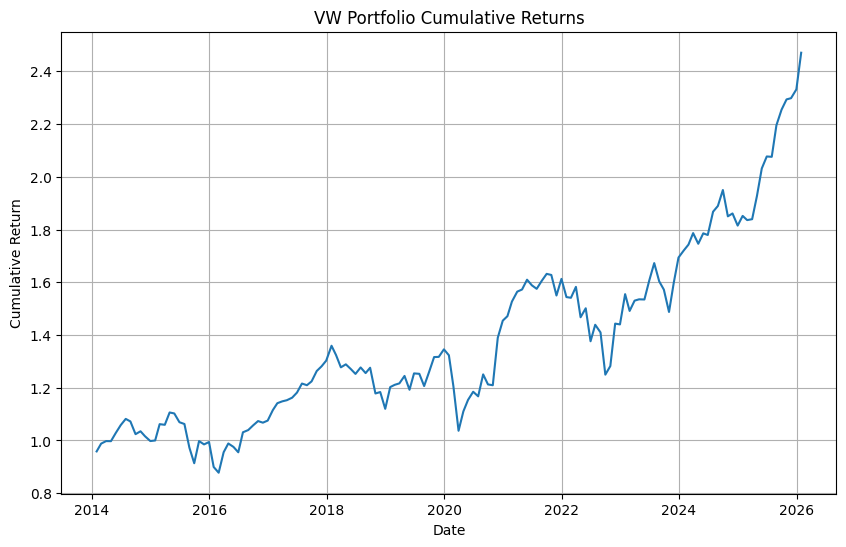

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ─────────────────────────────────────────────────────────────────
# 1. LOAD VALID UNIVERSE
# ─────────────────────────────────────────────────────────────────
def load_universe():
    """
    Read the ISINs that passed all filters in 02_analysis.py.
    These are the only firms eligible for the portfolio.
    """
    path = '../data/processed/final_returns_matrix.csv'
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found. Run src/02_analysis.py first.")

    ret = pd.read_csv(path, index_col=0)
    valid_isins = ret.columns.tolist()
    print(f"[load_universe] {len(valid_isins)} valid ISINs loaded.")
    return valid_isins


# ─────────────────────────────────────────────────────────────────
# 2. LOAD MARKET CAP
# ─────────────────────────────────────────────────────────────────
def load_market_cap(valid_isins):
    """
    Load annual market cap from Datastream (DS_MV_T_USD_Y.csv).
    Restrict to valid ISINs. Negative / zero values → NaN (unusable as weights).

    Returns DataFrame: rows = ISINs, columns = integer years.
    """
    mv = pd.read_csv('../data/raw/DS_MV_T_USD_Y.csv', skiprows=[1])
    mv = mv[mv['ISIN'].isin(valid_isins)].set_index('ISIN')
    mv = mv.drop(columns=['NAME'], errors='ignore')
    mv.columns = mv.columns.astype(int)
    mv = mv.apply(pd.to_numeric, errors='coerce')
    mv[mv <= 0] = np.nan

    n_with_mc = mv[2013].notna().sum()
    n_missing  = len(valid_isins) - n_with_mc
    print(f"[load_market_cap] Firms with 2013 market cap : {n_with_mc}")
    if n_missing:
        print(f"  WARNING: {n_missing} valid firms have no 2013 market cap — excluded from VW.")
    return mv


# ─────────────────────────────────────────────────────────────────
# 3. COMPUTE OUT-OF-SAMPLE RETURNS (2014 onward)
# ─────────────────────────────────────────────────────────────────
def compute_oos_returns(valid_isins, start='2014-01-01'):
    """
    Recompute returns from the full price series for the OOS period only.
    Applies the same cleaning rules as 02_analysis.py so returns are consistent.
    """
    prices_raw = pd.read_csv('../data/processed/Clean_Prices_Pacific.csv')
    prices = (
        prices_raw
        .set_index('ISIN')
        .drop(columns=['NAME'], errors='ignore')
        .T
    )
    prices.index = pd.to_datetime(prices.index)
    prices = prices[valid_isins].apply(pd.to_numeric, errors='coerce').sort_index()

    # Same cleaning as 02_analysis.py ─────────────────────────────
    prices[prices < 0.5] = np.nan

    non_nan        = prices.notna().astype(np.int8)
    cum_from_below = non_nan.iloc[::-1].cumsum(axis=0).iloc[::-1]
    trailing_mask  = prices.isna() & (cum_from_below == 0)
    prices         = prices.ffill(axis=0)
    prices[trailing_mask] = 0.0

    prev = prices.shift(1)
    ret  = (prices / prev.replace(0.0, np.nan)) - 1.0
    ret[(prices == 0.0) & (prev > 0.0)] = -1.0
    ret  = ret.replace([np.inf, -np.inf], np.nan)
    # ──────────────────────────────────────────────────────────────

    oos = ret.loc[start:]
    print(
        f"[compute_oos_returns] {oos.index[0].date()} → {oos.index[-1].date()} "
        f"({len(oos)} months)"
    )
    return oos


# ─────────────────────────────────────────────────────────────────
# 4. COMPUTE VW WEIGHTS PER FORMATION YEAR
# ─────────────────────────────────────────────────────────────────
def compute_vw_weights(mv, valid_isins, start_year=2013, end_year=2024):
    """
    For each formation year Y, weight_i = MktCap_i_Y / sum(MktCap_j_Y).
    Only firms with positive market cap in year Y receive a weight.
    Firms with missing market cap are excluded and weights renormalized.

    Returns: dict { formation_year: pd.Series of weights (index = ISIN) }
    """
    weights_per_year = {}

    for year in range(start_year, end_year + 1):
        if year not in mv.columns:
            continue
        mc = mv.loc[mv.index.intersection(valid_isins), year].dropna()
        if mc.empty or mc.sum() == 0:
            print(f"  {year}: no valid market cap — skipped.")
            continue

        w = mc / mc.sum()
        weights_per_year[year] = w
        print(
            f"  {year}: {len(w):>3} firms weighted | "
            f"largest: {w.max():.2%}  smallest: {w.min():.2%}  "
            f"HHI: {(w**2).sum():.4f}"
        )

    return weights_per_year


# ─────────────────────────────────────────────────────────────────
# 5. APPLY WEIGHTS → MONTHLY PORTFOLIO RETURNS
# ─────────────────────────────────────────────────────────────────
def compute_portfolio_returns(oos_ret, weights_per_year):
    """
    Annual rebalancing:
      - Month t belongs to year Y → use weights formed at end of year Y-1.
      - If a firm has NaN return in month t, its weight is redistributed
        proportionally to the remaining firms (renormalization).

    Fully vectorized within each calendar year.
    """
    chunks = []

    for ret_year in sorted(oos_ret.index.year.unique()):
        formation_year = ret_year - 1

        # Find closest available formation year (≤ formation_year)
        available = [y for y in weights_per_year if y <= formation_year]
        if not available:
            print(f"  {ret_year}: no formation weights available — skipped.")
            continue
        w = weights_per_year[max(available)]

        # Slice this calendar year's returns
        year_ret = oos_ret[oos_ret.index.year == ret_year]

        # Restrict to firms that have a weight (inner join on ISINs)
        common  = w.index.intersection(year_ret.columns)
        r_sub   = year_ret[common]               # (months × firms)
        w_vec   = w.loc[common].values           # (firms,)

        # Broadcast weights to a matrix and zero out NaN positions
        w_mat   = np.tile(w_vec, (len(r_sub), 1))          # (months × firms)
        valid   = r_sub.notna().values                      # (months × firms)
        w_mat   = w_mat * valid                             # zero missing firms
        row_sum = w_mat.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = np.nan
        w_mat   = w_mat / row_sum                           # renormalize each row

        monthly = pd.Series(
            (w_mat * r_sub.fillna(0).values).sum(axis=1),
            index=r_sub.index
        )
        # Months where ALL firms had NaN → set to NaN
        monthly[~valid.any(axis=1)] = np.nan
        chunks.append(monthly)

    if not chunks:
        return pd.Series(dtype=float, name='VW_Portfolio')

    port = pd.concat(chunks).sort_index()
    port.name = 'VW_Portfolio'
    return port


# ─────────────────────────────────────────────────────────────────
# 6. SAVE OUTPUTS AND PLOT
# ─────────────────────────────────────────────────────────────────
def save_and_plot(port_returns, weights_per_year):
    os.makedirs('../data/processed', exist_ok=True)
    os.makedirs('../outputs/figures', exist_ok=True)

    # Monthly returns CSV
    port_returns.to_csv('../data/processed/vw_portfolio_returns.csv', header=True)
    print("\nSaved → ../data/processed/vw_portfolio_returns.csv")

    # Weights per formation year CSV
    weights_df = pd.DataFrame(weights_per_year).T
    weights_df.index.name = 'formation_year'
    weights_df.to_csv('../data/processed/vw_weights_per_year.csv')
    print("Saved → ../data/processed/vw_weights_per_year.csv")

    # Annualized stats
    clean   = port_returns.dropna()
    ann_ret = clean.mean() * 12
    ann_vol = clean.std() * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    print("\n── VW Portfolio Performance ──────────────────────────")
    print(f"  Period            : {clean.index[0].date()} → {clean.index[-1].date()}")
    print(f"  Months            : {len(clean)}")
    print(f"  Annualized Return : {ann_ret:.2%}")
    print(f"  Annualized Volatility : {ann_vol:.2%}")
    print(f"  Sharpe Ratio : {sharpe:.2f}")

    # Plot cumulative returns
    cum_ret = (1 + clean).cumprod()
    plt.figure(figsize=(10, 6))
    plt.plot(cum_ret.index, cum_ret.values)
    plt.title('VW Portfolio Cumulative Returns')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.grid(True)
    plt.savefig('../outputs/figures/vw_portfolio_cumulative.png')
    plt.show()


# ─────────────────────────────────────────────────────────────────
# MAIN EXECUTION
# ─────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    valid_isins = load_universe()
    mv = load_market_cap(valid_isins)
    oos_ret = compute_oos_returns(valid_isins)
    weights_per_year = compute_vw_weights(mv, valid_isins)
    port_returns = compute_portfolio_returns(oos_ret, weights_per_year)
    save_and_plot(port_returns, weights_per_year)